# 06 – Model comparison

Bring the econometric and machine-learning forecasts together and compare out-of-sample performance.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

## Accuracy table

In [2]:
garch_results = pd.read_csv("../results/garch_model_comparison.csv")
ml_results = pd.read_csv("../results/ml_model_comparison.csv")

model_comparison = pd.concat(
    [garch_results, ml_results],
    ignore_index=True,
)

naive = model_comparison.loc[
    model_comparison["Model"] == "Naive"
].iloc[0]

for metric in ["MAE", "RMSE", "QLIKE"]:
    model_comparison[f"{metric}_improvement_vs_naive (%)"] = (
        (naive[metric] - model_comparison[metric]) / naive[metric] * 100
    )

model_comparison.sort_values("QLIKE").reset_index(drop=True)

,Model,MAE,RMSE,QLIKE,MAE_improvement_vs_naive (%),RMSE_improvement_vs_naive (%),QLIKE_improvement_vs_naive (%)
0,HAR-RV,0.474115,0.643004,0.236613,11.156625,11.072633,21.711343
1,XGBoost,0.526026,0.661889,0.245484,1.429247,8.460769,18.776220
2,Elastic Net,0.517746,0.644805,0.246191,2.980849,10.823596,18.542273
3,Random Forest,0.530517,0.666855,0.246232,0.587628,7.773966,18.528876
4,"GJR-GARCH(1,1)",0.691317,0.808089,0.253642,-29.544241,-11.758657,16.076864
5,"EGARCH(1,1)",0.693454,0.827625,0.259192,-29.944792,-14.460470,14.240504
6,"GARCH(1,1)",0.705010,0.818413,0.271446,-32.110103,-13.186462,10.185981
7,Naive,0.533653,0.723066,0.302232,0.000000,0.000000,0.000000


## Forecast-loss comparison

In [3]:
har_forecasts = pd.read_csv(
    "../results/har_rv_forecasts.csv",
    parse_dates=["target_date"],
)
garch_forecasts = pd.read_csv(
    "../results/garch_forecasts.csv",
    parse_dates=["target_date"],
)
ml_forecasts = pd.read_csv(
    "../results/ml_forecasts.csv",
    parse_dates=["target_date"],
)

forecasts = (
    har_forecasts[[
        "target_date",
        "actual_rv",
        "har_rv_forecast",
        "naive_rv_forecast",
    ]]
    .merge(
        garch_forecasts[[
            "target_date",
            "garch_rv_forecast",
            "gjr_rv_forecast",
            "egarch_rv_forecast",
        ]],
        on="target_date",
    )
    .merge(
        ml_forecasts[[
            "target_date",
            "elastic_rv_forecast",
            "rf_rv_forecast",
            "xgb_rv_forecast",
        ]],
        on="target_date",
    )
)

len(forecasts)

95

In [4]:
def qlike_loss(actual, forecast):
    ratio = actual / forecast
    return ratio - np.log(ratio) - 1


forecast_columns = {
    "Naive": "naive_rv_forecast",
    "GARCH(1,1)": "garch_rv_forecast",
    "GJR-GARCH(1,1)": "gjr_rv_forecast",
    "EGARCH(1,1)": "egarch_rv_forecast",
    "Elastic Net": "elastic_rv_forecast",
    "Random Forest": "rf_rv_forecast",
    "XGBoost": "xgb_rv_forecast",
}

har_loss = qlike_loss(
    forecasts["actual_rv"],
    forecasts["har_rv_forecast"],
)

test_results = []

for model, column in forecast_columns.items():
    competitor_loss = qlike_loss(forecasts["actual_rv"], forecasts[column])
    loss_diff = competitor_loss - har_loss

    result = sm.OLS(loss_diff, np.ones(len(loss_diff))).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 5},
    )

    test_results.append({
        "Model": model,
        "Mean loss difference": result.params.iloc[0],
        "P-value": result.pvalues.iloc[0],
    })

dm_results = pd.DataFrame(test_results)
dm_results

,Model,Mean loss difference,P-value
0,Naive,0.065619,0.049387
1,"GARCH(1,1)",0.034833,0.539985
2,"GJR-GARCH(1,1)",0.017029,0.773762
3,"EGARCH(1,1)",0.022579,0.727578
4,Elastic Net,0.009578,0.538202
5,Random Forest,0.009618,0.672895
6,XGBoost,0.008871,0.707575


## Figures

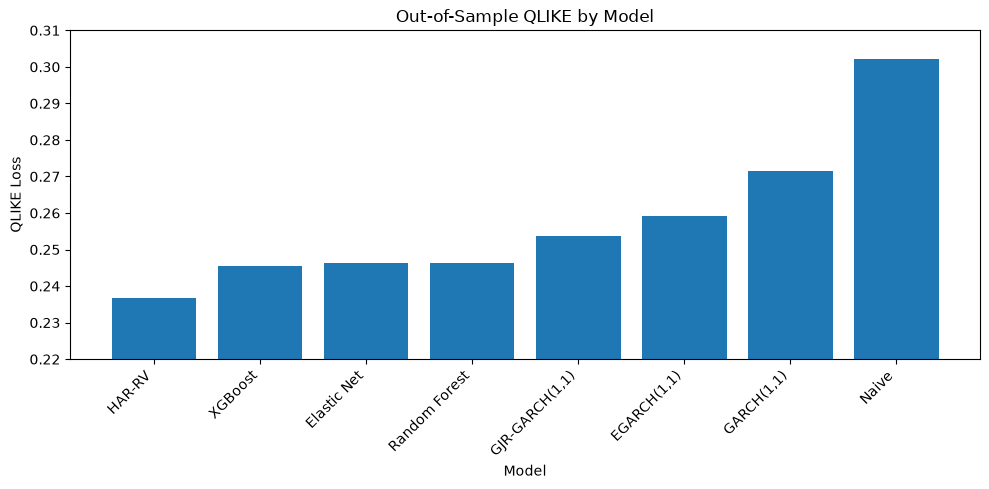

In [5]:
qlike_plot = model_comparison[
    ["Model", "QLIKE"]
].sort_values("QLIKE")

plt.figure(figsize=(10, 5))
plt.bar(qlike_plot["Model"], qlike_plot["QLIKE"])
plt.title("Out-of-Sample QLIKE by Model")
plt.xlabel("Model")
plt.ylabel("QLIKE Loss")
plt.ylim(0.22, 0.31)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../figures/model_qlike_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

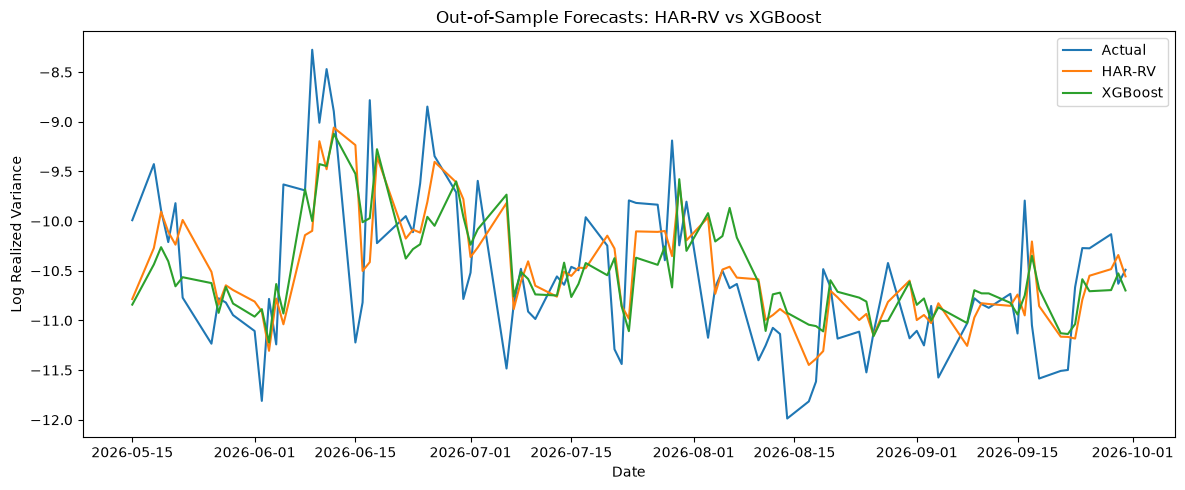

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(
    forecasts["target_date"],
    np.log(forecasts["actual_rv"]),
    label="Actual",
)
plt.plot(
    forecasts["target_date"],
    np.log(forecasts["har_rv_forecast"]),
    label="HAR-RV",
)
plt.plot(
    forecasts["target_date"],
    np.log(forecasts["xgb_rv_forecast"]),
    label="XGBoost",
)

plt.title("Out-of-Sample Forecasts: HAR-RV vs XGBoost")
plt.xlabel("Date")
plt.ylabel("Log Realized Variance")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/har_vs_xgboost_forecasts.png", dpi=300, bbox_inches="tight")
plt.show()

## Save final tables

In [7]:
final_results = (
    model_comparison[["Model", "MAE", "RMSE", "QLIKE"]]
    .sort_values("QLIKE")
    .reset_index(drop=True)
)

final_results.to_csv("../results/final_model_comparison.csv", index=False)
dm_results.to_csv("../results/forecast_accuracy_tests.csv", index=False)

final_results

,Model,MAE,RMSE,QLIKE
0,HAR-RV,0.474115,0.643004,0.236613
1,XGBoost,0.526026,0.661889,0.245484
2,Elastic Net,0.517746,0.644805,0.246191
3,Random Forest,0.530517,0.666855,0.246232
4,"GJR-GARCH(1,1)",0.691317,0.808089,0.253642
5,"EGARCH(1,1)",0.693454,0.827625,0.259192
6,"GARCH(1,1)",0.705010,0.818413,0.271446
7,Naive,0.533653,0.723066,0.302232


## Main findings

- HAR-RV achieved the lowest out-of-sample MAE, RMSE and QLIKE.
- Machine-learning models did not consistently outperform the simpler HAR-RV benchmark.
- GJR-GARCH and EGARCH captured asymmetric volatility responses.
- XGBoost relied most strongly on recent intraday price variation and short-horizon volatility measures.
- HAR-RV had the lowest QLIKE, but its advantage over the other econometric and machine-learning models was not statistically significant over the 95-day test period. The comparison with the naive benchmark was borderline at the 5% level.

## Conclusion

In this sample, the simpler realized-volatility model remained highly competitive. More flexible machine-learning models captured useful nonlinear patterns, but they did not produce a clear out-of-sample improvement over HAR-RV.